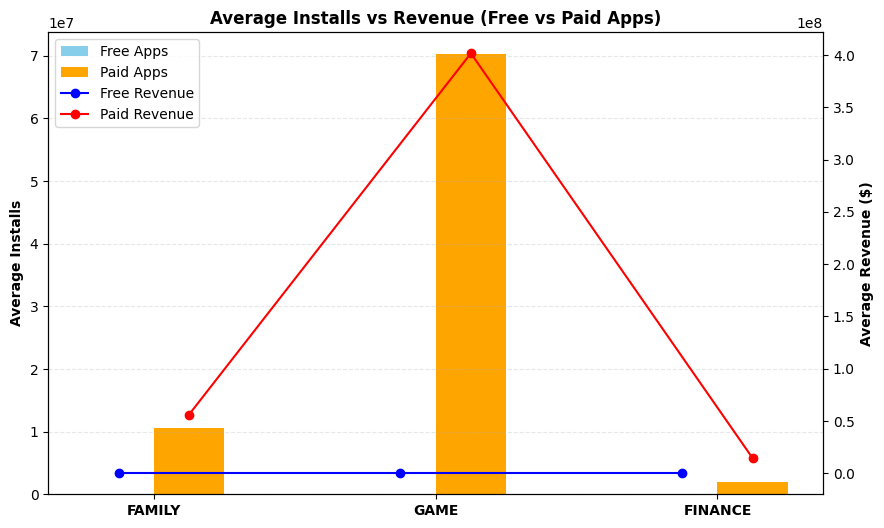

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pytz
import re

# ---------------------------------
# Step 1: Load Dataset
# ---------------------------------
file_path = "C:/Users/user/Downloads/internship/Play Store Data.csv"
df = pd.read_csv(file_path)

# ---------------------------------
# Step 2: Clean Columns
# ---------------------------------
df['Installs'] = df['Installs'].str.replace(',', '').str.replace('+', '')
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')
df = df.dropna(subset=['Installs'])
df['Installs'] = df['Installs'].astype(int)

def clean_android_ver(ver):
    if pd.isna(ver):
        return np.nan
    match = re.search(r"\d+(\.\d+)?", str(ver))
    return float(match.group()) if match else np.nan

df['Android Ver Num'] = df['Android Ver'].apply(clean_android_ver)

def clean_size(size):
    if pd.isna(size):
        return np.nan
    size = str(size).strip()
    if size == 'Varies with device':
        return np.nan
    if size.endswith('k'):
        try: return float(size[:-1]) / 1024
        except: return np.nan
    if size.endswith('M'):
        try: return float(size[:-1])
        except: return np.nan
    return np.nan

df['Size Num'] = df['Size'].apply(clean_size)

# ---------------------------------
# Step 3: Simulate Revenue
# ---------------------------------
np.random.seed(42)
df['sim_price'] = np.random.choice([0, 2, 5, 10], size=len(df), p=[0.7,0.1,0.1,0.1])
df['revenue'] = df['Installs'] * df['sim_price']
df['type'] = df['sim_price'].apply(lambda x: 'Free' if x==0 else 'Paid')

# ---------------------------------
# Step 4: Filters
# ---------------------------------
filters = {
    "Min Installs": 10000,
    "Min Revenue ($)": 10000,
    "Android Version >": 4.0,
    "App Size (MB) >": 15,
    "Content Rating": "Everyone",
    "App Name Length ≤": 30
}

filtered_df = df[
    (df['Installs'] >= filters["Min Installs"]) &
    (df['revenue'] >= filters["Min Revenue ($)"]) &
    (df['Android Ver Num'] > filters["Android Version >"]) &
    (df['Size Num'] > filters["App Size (MB) >"]) &
    (df['Content Rating'] == filters["Content Rating"]) &
    (df['App'].apply(lambda x: len(str(x)) <= filters["App Name Length ≤"]))
]

# ---------------------------------
# Step 5: Top 3 Categories
# ---------------------------------
top_categories = filtered_df['Category'].value_counts().nlargest(3).index.tolist()
filtered_df = filtered_df[filtered_df['Category'].isin(top_categories)]

agg_df = (
    filtered_df.groupby(['Category','type'])
    .agg({'Installs':'mean','revenue':'mean'})
    .reset_index()
)

# ---------------------------------
# Step 6: Plot Chart
# ---------------------------------
fig, ax1 = plt.subplots(figsize=(10,6))
width = 0.25
x = np.arange(len(top_categories))

free_installs = []
paid_installs = []
free_revenue = []
paid_revenue = []

for cat in top_categories:
    free_data = agg_df[(agg_df['Category']==cat) & (agg_df['type']=='Free')]
    paid_data = agg_df[(agg_df['Category']==cat) & (agg_df['type']=='Paid')]

    free_installs.append(free_data['Installs'].values[0] if len(free_data)>0 else 0)
    paid_installs.append(paid_data['Installs'].values[0] if len(paid_data)>0 else 0)
    free_revenue.append(free_data['revenue'].values[0] if len(free_data)>0 else 0)
    paid_revenue.append(paid_data['revenue'].values[0] if len(paid_data)>0 else 0)

ax1.bar(x - width/2, free_installs, width=width, color='skyblue', label='Free Apps')
ax1.bar(x + width/2, paid_installs, width=width, color='orange', label='Paid Apps')

ax1.set_xticks(x)
ax1.set_xticklabels(top_categories, fontweight='bold')
ax1.set_ylabel("Average Installs", fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(x - width/2, free_revenue, 'o-', color='blue', label='Free Revenue')
ax2.plot(x + width/2, paid_revenue, 'o-', color='red', label='Paid Revenue')
ax2.set_ylabel("Average Revenue ($)", fontweight='bold')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title("Average Installs vs Revenue (Free vs Paid Apps)", fontweight='bold')
plt.show()
